# TSP (Travelling Salesman Problem)

## Importation des algorithmes

In [45]:

from algo import algorithme, algorithme2
from utils import *
from algo.aco import aco_solve, format_solution


### Déclaration des variables

In [36]:
random_n = 10 # Nombre de points de livraison
ratio_express = 0.4 # Ratio des points de livraison express
points = make_demo_points(random_n, ratio_express)

alpha = 1.0 # Influence la durée globale du tour
beta = 1.0 # Influence la priorité des clients
max_hours = 8.0 # Durée maximale de la tournée (8 h)
speed = 30 # Convertit les distances en heures de trajet

n_express = sum(point.est_express for point in points)
w_express = ((random_n - n_express - 1)/(random_n - (random_n - n_express - 1))) + 1 # Importance des clients prioritaires
w_normal = 1/(1 + w_express) # Importance des clients standards

## Utilisation des différents algorithmes pour résoudre TSP

### Algorithme de Christophides Personnalisé


=== DÉBUT TSP PONDÉRÉ ===
Dépôt : Point(x=0.0, y=0.0, est_express=False)
Points express (40): [1, 8, 9, 14, 15, 16, 17, 19, 20, 23, 30, 32, 35, 38, 39, 40, 42, 44, 45, 50, 52, 53, 59, 62, 63, 64, 66, 68, 73, 75, 77, 86, 88, 90, 92, 93, 94, 96, 97, 98]
Points normaux (59): [2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 18, 21, 22, 24, 25, 26, 27, 28, 29, 31, 33, 34, 36, 37, 41, 43, 46, 47, 48, 49, 51, 54, 55, 56, 57, 58, 60, 61, 65, 67, 69, 70, 71, 72, 74, 76, 78, 79, 80, 81, 82, 83, 84, 85, 87, 89, 91, 95, 99]
Tour express (indices): [0, 23, 16, 15, 62, 93, 38, 53, 77, 45, 39, 96, 68, 90, 66, 98, 19, 40, 14, 94, 73, 75, 35, 17, 8, 44, 88, 9, 63, 92, 86, 59, 50, 20, 1, 42, 30, 52, 97, 64, 32, 0]
Tour final (indices): [0, 23, 16, 15, 62, 93, 38, 53, 77, 45, 39, 96, 68, 90, 66, 98, 19, 40, 14, 94, 73, 75, 35, 17, 8, 44, 88, 9, 63, 92, 86, 59, 50, 20, 1, 42, 30, 52, 97, 64, 32, 5, 4, 56, 70, 85, 18, 27, 24, 84, 83, 67, 51, 21, 13, 41, 99, 76, 58, 60, 81, 28, 80, 78, 31, 2, 71, 55, 10, 43, 65, 87, 74,

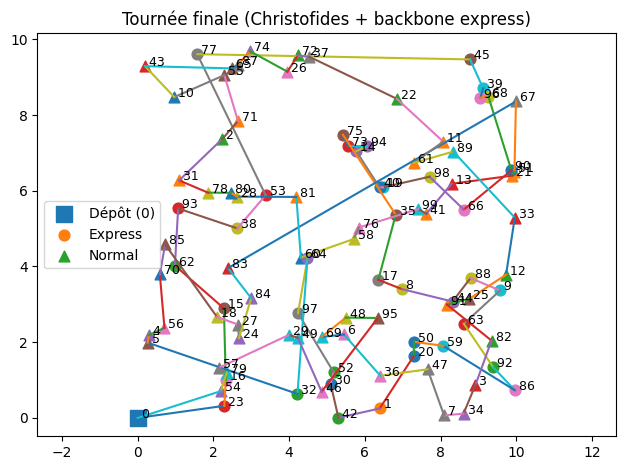

In [15]:
algorithme2.run(points, alpha, beta, w_express, w_normal, max_hours, speed)

### Algorithme Personnalisé


--- Résultats ---
Tour (indices): [0, 23, 54, 16, 79, 57, 18, 15, 62, 85, 93, 38, 53, 2, 77, 55, 65, 87, 26, 72, 37, 45, 39, 96, 68, 90, 51, 21, 66, 13, 98, 19, 40, 14, 94, 73, 75, 35, 17, 8, 91, 44, 88, 9, 25, 63, 82, 92, 86, 3, 59, 50, 20, 1, 42, 30, 52, 49, 29, 97, 60, 64, 48, 6, 69, 32, 46, 7, 34, 47, 36, 95, 24, 27, 84, 56, 4, 5, 70, 83, 28, 80, 78, 31, 10, 43, 71, 74, 22, 11, 61, 99, 41, 89, 67, 33, 12, 76, 58, 81, 0]
Heures d'arrivée (par position dans le tour):
[0.0, 0.077, 0.09, 0.101, 0.108, 0.116, 0.161, 0.17, 0.228, 0.248, 0.282, 0.337, 0.375, 0.438, 0.516, 0.546, 0.555, 0.561, 0.605, 0.622, 0.632, 0.774, 0.802, 0.81, 0.817, 0.885, 0.888, 0.892, 0.944, 0.969, 0.99, 1.032, 1.035, 1.073, 1.083, 1.099, 1.11, 1.194, 1.254, 1.276, 1.318, 1.323, 1.349, 1.378, 1.406, 1.428, 1.457, 1.48, 1.508, 1.543, 1.587, 1.614, 1.626, 1.681, 1.718, 1.749, 1.76, 1.803, 1.812, 1.832, 1.881, 1.887, 1.949, 1.964, 1.984, 2.039, 2.06, 2.17, 2.187, 2.237, 2.279, 2.33, 2.454, 2.465, 2.491, 2.572, 2.58

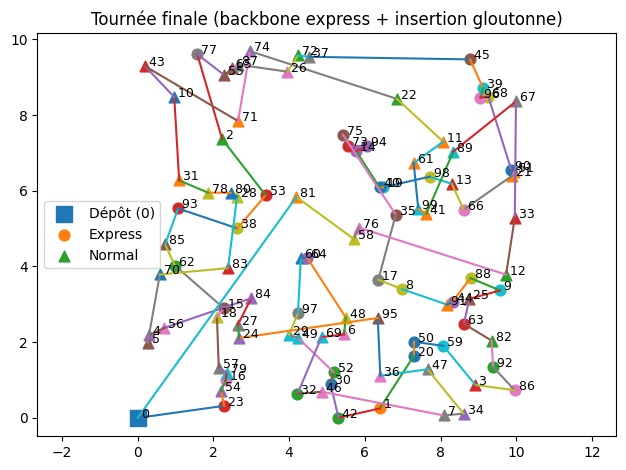

In [14]:
algorithme.run(points, alpha, beta, w_express, w_normal, max_hours, speed)

## Méta Heuristique

In [13]:
sol = aco_solve(
    points,
    alpha=alpha,
    beta=beta,
    speed=speed,
    max_hours=max_hours,
    ants=len(points),        # raisonnable: ~n
    iterations=250,          # augmente pour de meilleurs résultats
    rho=0.4,
    Q=1.0,
    seed=1,
    # Optionnel: surpondérer les express si tu veux insister encore plus
    # w_express=3.0, w_normal=1.0,
)

print(format_solution(sol, points))

Objectif I = 299.329
Temps total T = 4.993 h ; distance = 149.801 unités
Ordre de visite (indices): 0 -> 97 -> 29 -> 49 -> 69 -> 6 -> 46 -> 32 -> 23 -> 54 -> 79 -> 24 -> 18 -> 15 -> 27 -> 16 -> 30 -> 42 -> 7 -> 86 -> 92 -> 3 -> 34 -> 47 -> 8 -> 50 -> 20 -> 59 -> 12 -> 9 -> 82 -> 63 -> 91 -> 44 -> 25 -> 95 -> 17 -> 64 -> 60 -> 81 -> 53 -> 19 -> 40 -> 89 -> 11 -> 13 -> 94 -> 61 -> 98 -> 99 -> 41 -> 68 -> 96 -> 39 -> 45 -> 58 -> 76 -> 1 -> 36 -> 88 -> 33 -> 51 -> 90 -> 21 -> 67 -> 66 -> 35 -> 14 -> 73 -> 75 -> 22 -> 37 -> 26 -> 77 -> 65 -> 87 -> 55 -> 74 -> 71 -> 2 -> 31 -> 38 -> 93 -> 85 -> 62 -> 5 -> 56 -> 4 -> 70 -> 83 -> 84 -> 57 -> 78 -> 80 -> 28 -> 10 -> 43 -> 72 -> 48 -> 52 -> 0
Visités: express=40, normal=59


## Affichage des Complexités avec un graphique temporelle

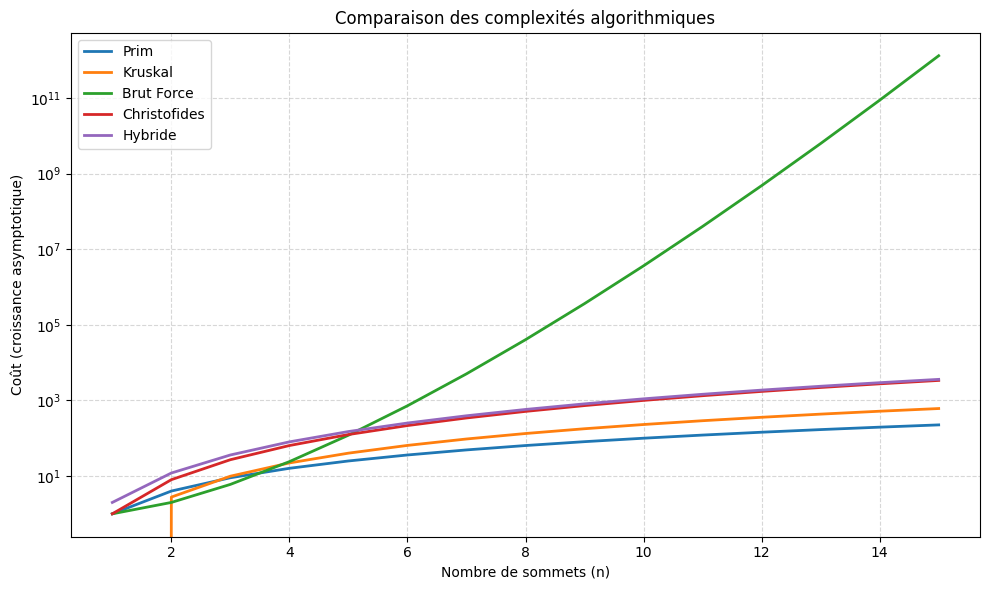

In [6]:
plot_complexity_comparison(
    [
        lambda n: n**2,                  # Prim
        lambda n: n**2 * math.log(n),    # Kruskal
        lambda n: math.factorial(n),     # Brute Force
        lambda n: n**3,                  # Christofides
        lambda n: n**3 + n**2            # Hybride (Christofides + Insertion gloutonne)
    ],
    ["Prim", "Kruskal", "Brut Force", "Christofides", "Hybride"],
    n_max=15
)
